In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to  : {SEED}')


TensorFlow version : 2.20.0
Random seed set to  : 42


In [3]:
RESULTS_DIR = '/content/drive/MyDrive/ME20/results/'
MODEL_DIR   = '/content/drive/MyDrive/ME20/model/'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)
print('Results will be saved to:', RESULTS_DIR)
print('Models  will be saved to:', MODEL_DIR)


Results will be saved to: /content/drive/MyDrive/ME20/results/
Models  will be saved to: /content/drive/MyDrive/ME20/model/


In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('No GPU found — training will run on CPU.')


GPUs available: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
import kagglehub

# Dataset: pacificrm/skindiseasedataset
# Structure: SkinDisease/train/<ClassName>/  and  SkinDisease/test/<ClassName>/
# We only use Acne and Eczema from both splits.
path = kagglehub.dataset_download('pacificrm/skindiseasedataset')
print('Path to dataset files:', path)


Using Colab cache for faster access to the 'skindiseasedataset' dataset.
Path to dataset files: /kaggle/input/skindiseasedataset


In [6]:
# Walk the top levels to confirm structure
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 3:
        print('  ' * depth + Path(root).name)


skindiseasedataset
  SkinDisease
    SkinDisease
      test
      train


In [7]:
# Locate the Acne and Eczema folders inside train/ and test/
# The dataset already has train and test splits, so we use them directly
# and carve out a val set from train (15% of each class).

TARGET_CLASSES = ['Acne', 'Eczema']

src_train = {}
src_test  = {}

for dirpath, dirnames, _ in os.walk(path):
    name   = Path(dirpath).name
    parent = Path(dirpath).parent.name.lower()
    for cls in TARGET_CLASSES:
        if name.lower() == cls.lower():
            if parent == 'train':
                src_train[cls] = Path(dirpath)
            elif parent == 'test':
                src_test[cls]  = Path(dirpath)

print('Train sources:')
for k, v in src_train.items():
    print(f'  {k}: {v}')
print('Test sources:')
for k, v in src_test.items():
    print(f'  {k}: {v}')

for cls in TARGET_CLASSES:
    assert cls in src_train, f'Could not find {cls} inside train/'
    assert cls in src_test,  f'Could not find {cls} inside test/'


Train sources:
  Eczema: /kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/train/Eczema
  Acne: /kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/train/Acne
Test sources:
  Eczema: /kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Eczema
  Acne: /kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Acne


In [8]:
def count_images(d):
    if d is None or not Path(d).exists():
        return 0
    exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    return sum(len(list(Path(d).rglob(e))) for e in exts)

print('Image counts in source folders:')
for cls in TARGET_CLASSES:
    n_tr = count_images(src_train[cls])
    n_te = count_images(src_test[cls])
    print(f'  {cls:<10}  train={n_tr}  test={n_te}')


Image counts in source folders:
  Acne        train=593  test=65
  Eczema      train=1010  test=112


In [9]:
# Build train / val / test splits:
#   - test  : taken directly from the dataset's test/ folder
#   - train : 85% of the dataset's train/ folder  (per class)
#   - val   : 15% of the dataset's train/ folder  (per class)

SPLIT_ROOT = '/content/acne_eczema_split'
VAL_RATIO  = 0.15

def build_splits(split_root, src_train, src_test, target_classes, val_ratio, seed=42):
    rng  = random.Random(seed)
    exts = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    for split in ('train', 'val', 'test'):
        for cls in target_classes:
            os.makedirs(os.path.join(split_root, split, cls), exist_ok=True)

    for cls in target_classes:
        # test: copy straight from kaggle test folder
        test_imgs = [p for p in Path(src_test[cls]).iterdir()
                     if p.is_file() and p.suffix in exts]
        dst_test = os.path.join(split_root, 'test', cls)
        for img in test_imgs:
            shutil.copy2(img, os.path.join(dst_test, img.name))

        # train + val: split kaggle train folder 85/15
        train_imgs = [p for p in Path(src_train[cls]).iterdir()
                      if p.is_file() and p.suffix in exts]
        rng.shuffle(train_imgs)

        n_val      = max(1, int(len(train_imgs) * val_ratio))
        val_imgs   = train_imgs[:n_val]
        train_imgs = train_imgs[n_val:]

        for split_name, imgs in [('train', train_imgs), ('val', val_imgs)]:
            dst = os.path.join(split_root, split_name, cls)
            for img in imgs:
                shutil.copy2(img, os.path.join(dst, img.name))

        print(f'  {cls:<10}  train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}')

if not Path(SPLIT_ROOT).exists():
    print('Building train / val / test split...')
    build_splits(SPLIT_ROOT, src_train, src_test, TARGET_CLASSES, VAL_RATIO, seed=SEED)
    print('Done.')
else:
    print('Split already exists at', SPLIT_ROOT)


Building train / val / test split...
  Acne        train=505  val=88  test=65
  Eczema      train=859  val=151  test=112
Done.


In [10]:
for split in ('train', 'val', 'test'):
    split_path = Path(SPLIT_ROOT) / split
    total = count_images(split_path)
    print(f'{split:>5} : {total} total')
    for cls_dir in sorted(split_path.iterdir()):
        print(f'         {cls_dir.name:<12}: {count_images(cls_dir)}')


train : 1364 total
         Acne        : 505
         Eczema      : 859
  val : 239 total
         Acne        : 88
         Eczema      : 151
 test : 177 total
         Acne        : 65
         Eczema      : 112


In [11]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4

print(f'Image size   : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Learning rate: {LR}')


Image size   : 224 x 224
Batch size   : 32
Max epochs   : 20
Learning rate: 0.0001


In [12]:
train_dir = Path(SPLIT_ROOT) / 'train'
val_dir   = Path(SPLIT_ROOT) / 'val'
test_dir  = Path(SPLIT_ROOT) / 'test'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=True,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)


Found 1364 files belonging to 2 classes.
Found 239 files belonging to 2 classes.
Found 177 files belonging to 2 classes.


In [13]:
class_names = train_dataset.class_names
print(f'Classes: {class_names}')
# Expected: ['Acne', 'Eczema']  (alphabetical)
# raw_prob = P(Eczema) = P(CLASS_NAMES[1])

if len(class_names) != 2:
    print(f'WARNING: expected 2 classes, found {len(class_names)}: {class_names}')


Classes: ['Acne', 'Eczema']


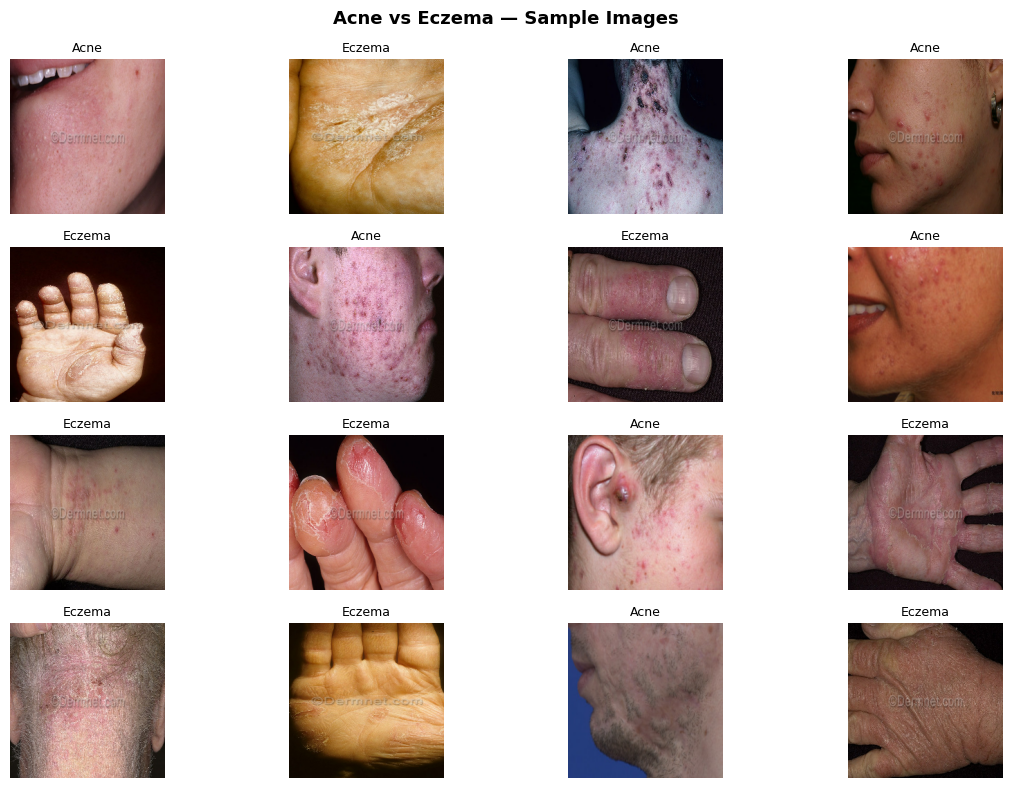

In [14]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')

plt.suptitle('Acne vs Eczema — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print('Pipeline optimised with cache + shuffle + prefetch.')


Pipeline optimised with cache + shuffle + prefetch.


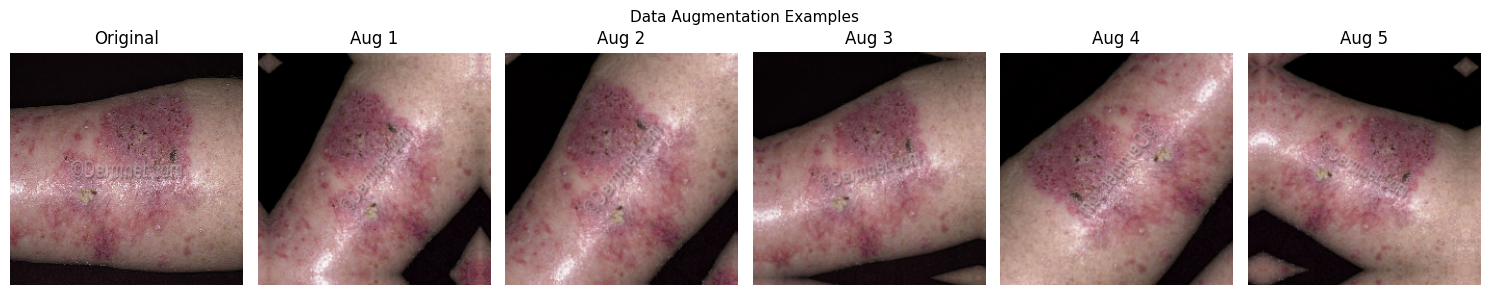

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name='data_augmentation')

for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 6):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}'); axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()


In [17]:
def make_callbacks(name, model_dir=MODEL_DIR):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(model_dir, f'{name}_best.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=3, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label='Train Accuracy',      linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label='Train Loss',      linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, class_names, title='Model'):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs); y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f'\n{title}')
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()
    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')


Callbacks and utility functions defined.


In [18]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_transfer_model(input_shape, augmentation):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet', input_shape=input_shape, include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    inputs  = tf.keras.Input(shape=input_shape)
    x       = augmentation(inputs)
    x       = preprocess_fn(x)
    x       = base_model(x, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.Dense(128, activation='relu')(x)
    x       = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='mobilenetv2_skin'), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model      : mobilenetv2_1.00_224
Trainable layers: 0 / 154


Model: "mobilenetv2_skin"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# Phase 1 — Feature Extraction (base frozen)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy', metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset, validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('mobilenetv2_acne_eczema_feature_extraction'),
    verbose=1,
)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5769 - loss: 0.7593
Epoch 1: val_accuracy improved from None to 0.81590, saving model to /content/drive/MyDrive/ME20/model/mobilenetv2_acne_eczema_feature_extraction_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME20/model/mobilenetv2_acne_eczema_feature_extraction_best.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.6826 - loss: 0.6142 - val_accuracy: 0.8159 - val_loss: 0.4034 - learning_rate: 1.0000e-04
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8173 - loss: 0.4134
Epoch 2: val_accuracy improved from 0.81590 to 0.82427, saving model to /content/drive/MyDrive/ME20/model/mobilenetv2_acne_eczema_feature_extraction_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ME20/model/mobilenetv2_acne_eczema_feature_extraction_best.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8292 - loss: 0.3866 - val_accuracy: 0.8243 - val_loss: 0.3343 - lea

MobileNetV2 TL -> val_loss    : 0.1765
MobileNetV2 TL -> val_accuracy: 0.9163


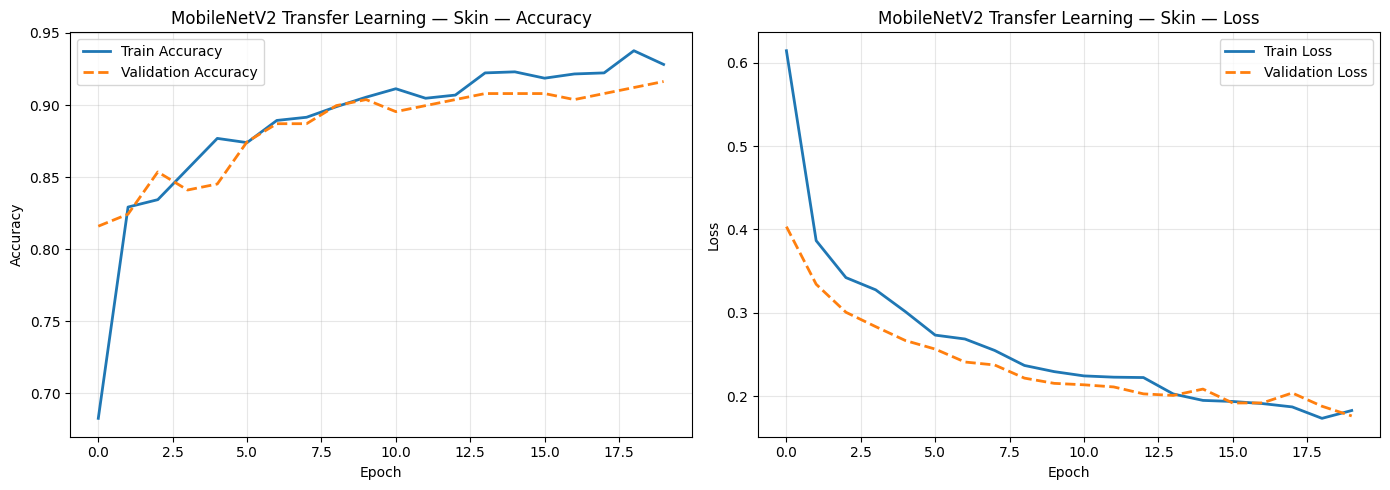

In [20]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV2 TL -> val_loss    : {tl_val_loss:.4f}')
print(f'MobileNetV2 TL -> val_accuracy: {tl_val_acc:.4f}')

plot_learning_curves(tl_history, 'MobileNetV2 Transfer Learning — Skin')



MobileNetV2 Transfer — Skin
Accuracy  : 0.9209
Precision : 0.9224
Recall    : 0.9554
F1-Score  : 0.9386

Classification Report:
              precision    recall  f1-score   support

        Acne     0.9180    0.8615    0.8889        65
      Eczema     0.9224    0.9554    0.9386       112

    accuracy                         0.9209       177
   macro avg     0.9202    0.9084    0.9137       177
weighted avg     0.9208    0.9209    0.9203       177



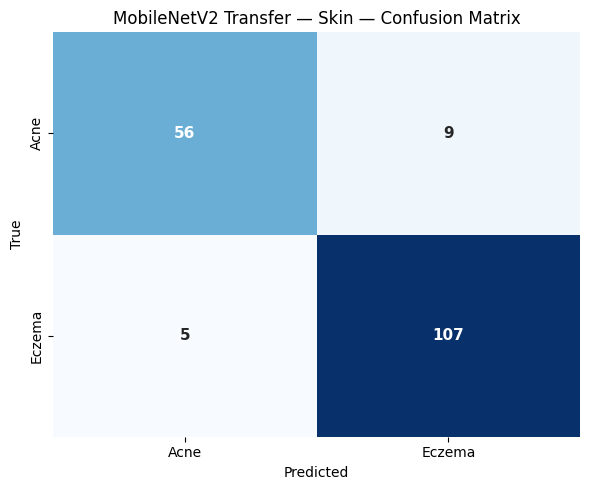

In [21]:
tl_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Transfer — Skin'
)


In [22]:
# Phase 2 — Fine-Tuning (unfreeze top 30 layers of the base)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')


Trainable base layers after unfreezing: 30 / 154


In [23]:
FINETUNE_LR = LR / 10   # 1e-5

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='binary_crossentropy', metrics=['accuracy'],
)


In [24]:
ft_history = tl_model.fit(
    train_dataset, validation_data=val_dataset,
    epochs=10,
    callbacks=make_callbacks('mobilenetv2_acne_eczema_finetuned'),
    verbose=1,
)


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8647 - loss: 0.3265
Epoch 1: val_accuracy improved from None to 0.92469, saving model to /content/drive/MyDrive/ME20/model/mobilenetv2_acne_eczema_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME20/model/mobilenetv2_acne_eczema_finetuned_best.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 147ms/step - accuracy: 0.8695 - loss: 0.3188 - val_accuracy: 0.9247 - val_loss: 0.1736 - learning_rate: 1.0000e-05
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8656 - loss: 0.2704
Epoch 2: val_accuracy did not improve from 0.92469
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.8629 - loss: 0.2862 - val_accuracy: 0.9205 - val_loss: 0.1863 - learning_rate: 1.0000e-05
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8769 - loss: 0.2564
Epoch 3: val_accuracy did not improve from 0.92469
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.8922 - loss: 0.2410 - val_accuracy: 0

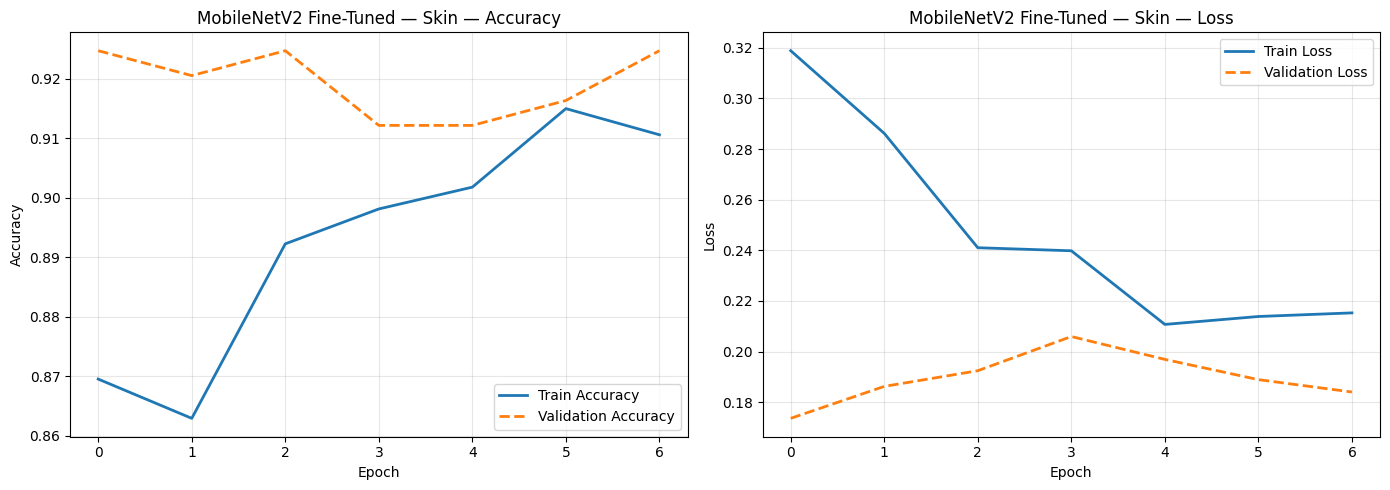


MobileNetV2 Fine-Tuned — Skin
Accuracy  : 0.9040
Precision : 0.9358
Recall    : 0.9107
F1-Score  : 0.9231

Classification Report:
              precision    recall  f1-score   support

        Acne     0.8529    0.8923    0.8722        65
      Eczema     0.9358    0.9107    0.9231       112

    accuracy                         0.9040       177
   macro avg     0.8944    0.9015    0.8976       177
weighted avg     0.9054    0.9040    0.9044       177



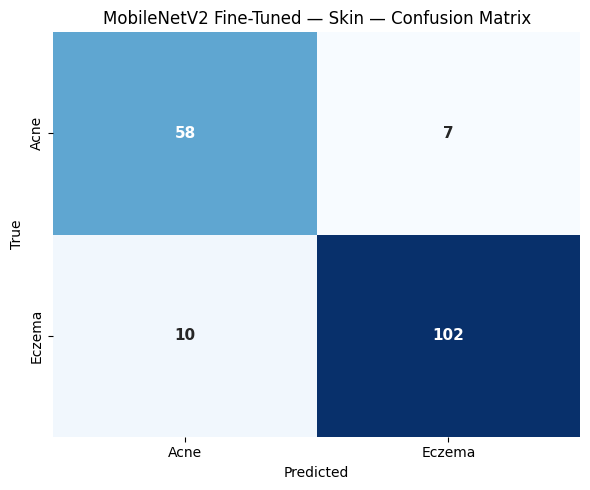


--- Summary ---
Feature-extraction test accuracy : 0.9209
Fine-tuned         test accuracy : 0.9040


In [25]:
plot_learning_curves(ft_history, 'MobileNetV2 Fine-Tuned — Skin')

ft_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Fine-Tuned — Skin'
)

print('\n--- Summary ---')
print(f'Feature-extraction test accuracy : {tl_test_acc:.4f}')
print(f'Fine-tuned         test accuracy : {ft_test_acc:.4f}')


In [26]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    img       = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    prob       = model.predict(img_array, verbose=0)[0][0]
    label      = class_names[int(prob >= 0.5)]
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'Prediction : {label}')
    print(f'Confidence : {confidence:.4f}')

print('predict_image() utility defined.')


predict_image() utility defined.


In [27]:
FINAL_MODEL_PATH = '/content/drive/MyDrive/ME20/model/acne_eczema_model.keras'
tl_model.save(FINAL_MODEL_PATH)

print('Model saved:')
print(f'  {FINAL_MODEL_PATH}')
print(f'  Final test accuracy: {ft_test_acc:.4f}')


Model saved:
  /content/drive/MyDrive/ME20/model/acne_eczema_model.keras
  Final test accuracy: 0.9040


In [28]:
# ── Generate class_stats.npz for OOD Layer 2 ─────────────────────────────────────────────
# Run this cell ONCE after training.
# We reload val images directly from disk (no augmentation pipeline) so the
# per-class feature statistics are clean and stable — matching what app.py
# sees at inference time.

import numpy as np
import keras

CLASS_STATS_PATH = FINAL_MODEL_PATH.replace(FINAL_MODEL_PATH.split('/')[-1], 'class_stats.npz')

# Load the saved model
saved_model = keras.models.load_model(FINAL_MODEL_PATH)
print('Model loaded from:', FINAL_MODEL_PATH)

# Build feature extractor: model.input → GlobalAveragePooling2D
gap_layer = next(
    l for l in reversed(saved_model.layers)
    if isinstance(l, keras.layers.GlobalAveragePooling2D)
)
feature_extractor = keras.Model(
    inputs=saved_model.input,
    outputs=gap_layer.output,
    name='feature_extractor',
)
print(f'Feature extractor output shape: {feature_extractor.output_shape}')

# Reload val set FRESH from disk (no cache, no augmentation)
# This ensures features match exactly what app.py computes at inference time.
val_dataset_clean = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

# Collect features and labels
all_features, all_labels = [], []
for imgs, lbls in val_dataset_clean:
    feats = feature_extractor(imgs, training=False).numpy()
    all_features.append(feats)
    all_labels.append(lbls.numpy().flatten())

all_features = np.concatenate(all_features, axis=0)  # (N, 1280)
all_labels   = np.concatenate(all_labels,   axis=0)  # (N,)
print(f'Collected {len(all_features)} val samples, feature dim={all_features.shape[1]}')

# Compute per-class mean and std
class_means, class_stds = [], []
for idx, name in enumerate(class_names):
    mask        = all_labels == idx
    class_feats = all_features[mask]
    class_means.append(class_feats.mean(axis=0))
    class_stds.append(class_feats.std(axis=0) + 1e-8)  # avoid div-by-zero
    print(f'  {name}: {mask.sum()} samples')

class_means = np.array(class_means)  # (n_classes, 1280)
class_stds  = np.array(class_stds)   # (n_classes, 1280)

# Save to Drive
np.savez(CLASS_STATS_PATH, means=class_means, stds=class_stds, class_names=class_names)
print(f'\nclass_stats.npz saved to: {CLASS_STATS_PATH}')
print('OOD Layer 2 is now enabled in the Streamlit app.')


Model loaded from: /content/drive/MyDrive/ME20/model/acne_eczema_model.keras
Feature extractor output shape: (None, 1280)
Collected 239 val samples, feature dim=1280
  Acne: 88 samples
  Eczema: 151 samples

class_stats.npz saved to: /content/drive/MyDrive/ME20/model/class_stats.npz
OOD Layer 2 is now enabled in the Streamlit app.
